In [3]:
%pip install opencv-python matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Ilham Febriyansyah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
    --------------------------------------- 0.8/44.0 MB 2.1 MB/s eta 0:00:21
    --------------------------------------- 0.8/44.0 MB 2.1 MB/s eta 0:00:21
   - -------------------------------------- 2.1/44.0 MB 2.9 MB/s eta 0:00:15
   -- ------------------------------------- 3.1/44.0 MB 3.3 MB/s eta 0:00:13
   ---- ----------------------------------- 4.5/44.0 MB 3.8 MB/s eta 0:00:11
   ----- ---------------------------------- 6.0/44.0 MB 4.3 MB/s eta 0:00:09
   ----- ---------------------------------- 6.3/44.0 MB 4.3 MB/s eta 0:00:09
   ------- -------------------------------- 8.4/44.0 MB 4.6 MB/s eta 0:00:08
   -------- ------------------------------- 9.2/44.0 MB 4.5 MB/s eta 0:00:08
   ---------- ----------------------------- 11.0/44.0 MB 4.7 MB/s eta 0:00:08
   --------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\Ilham Febriyansyah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


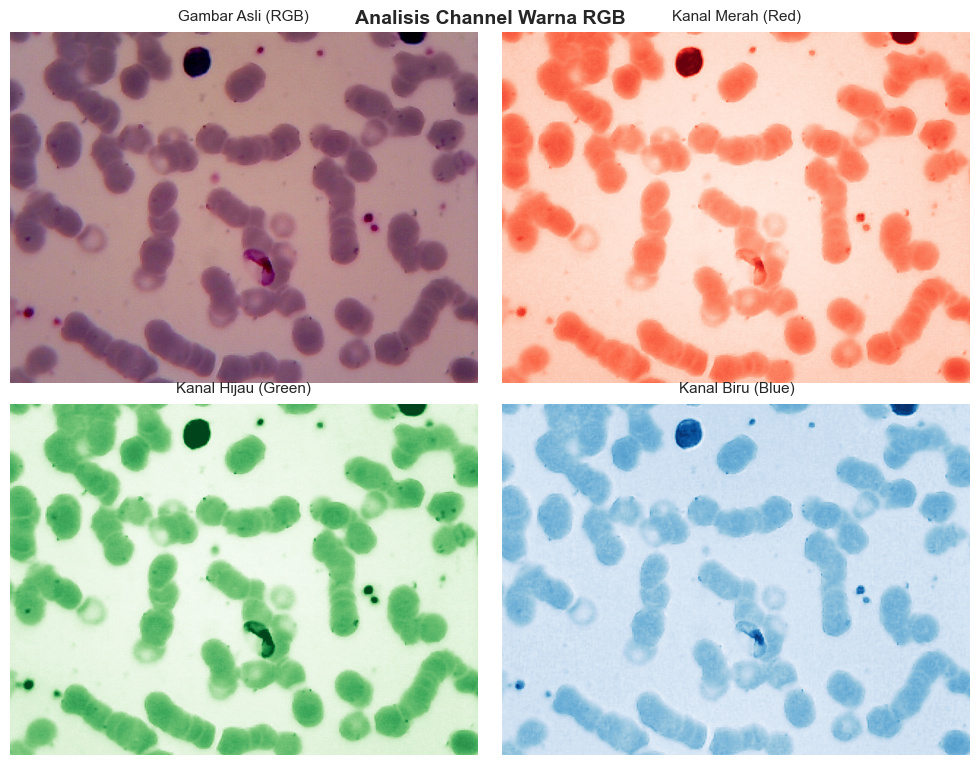

In [6]:
import cv2
import matplotlib.pyplot as plt
import os

# --- 1. Konfigurasi Path File ---
filename = "FG.png"

# Pastikan file ada sebelum dibaca untuk menghindari Assertion error
if not os.path.exists(filename):
    raise FileNotFoundError(f"File '{filename}' tidak ditemukan di folder kerja saat ini: {os.getcwd()}")

# --- 2. Pemrosesan Gambar ---
img_bgr = cv2.imread(filename)

if img_bgr is None:
    raise ValueError("Gagal membaca file gambar. Periksa format file.")

# Konversi BGR ke RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Akses channel langsung menggunakan indeks array (lebih efisien daripada cv2.split)
r_channel = img_rgb[:, :, 0]
g_channel = img_rgb[:, :, 1]
b_channel = img_rgb[:, :, 2]

# --- 3. Visualisasi (Grid 2x2 dengan Kustomisasi Style) ---
# Menggunakan style modern dan tata letak 2x2
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
fig.suptitle("Analisis Channel Warna RGB", fontsize=14, fontweight='bold', y=0.95)

# Daftar konfigurasi untuk perulangan
channels = [
    (img_rgb, "Gambar Asli (RGB)", None),
    (r_channel, "Kanal Merah (Red)", "Reds_r"),
    (g_channel, "Kanal Hijau (Green)", "Greens_r"),
    (b_channel, "Kanal Biru (Blue)", "Blues_r")
]

# Plot elemen menggunakan loop agar kode lebih rapi
for ax, (data, title, cmap) in zip(axes.flat, channels):
    if cmap:
        ax.imshow(data, cmap=cmap)
    else:
        ax.imshow(data)
    
    ax.set_title(title, fontsize=11, pad=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

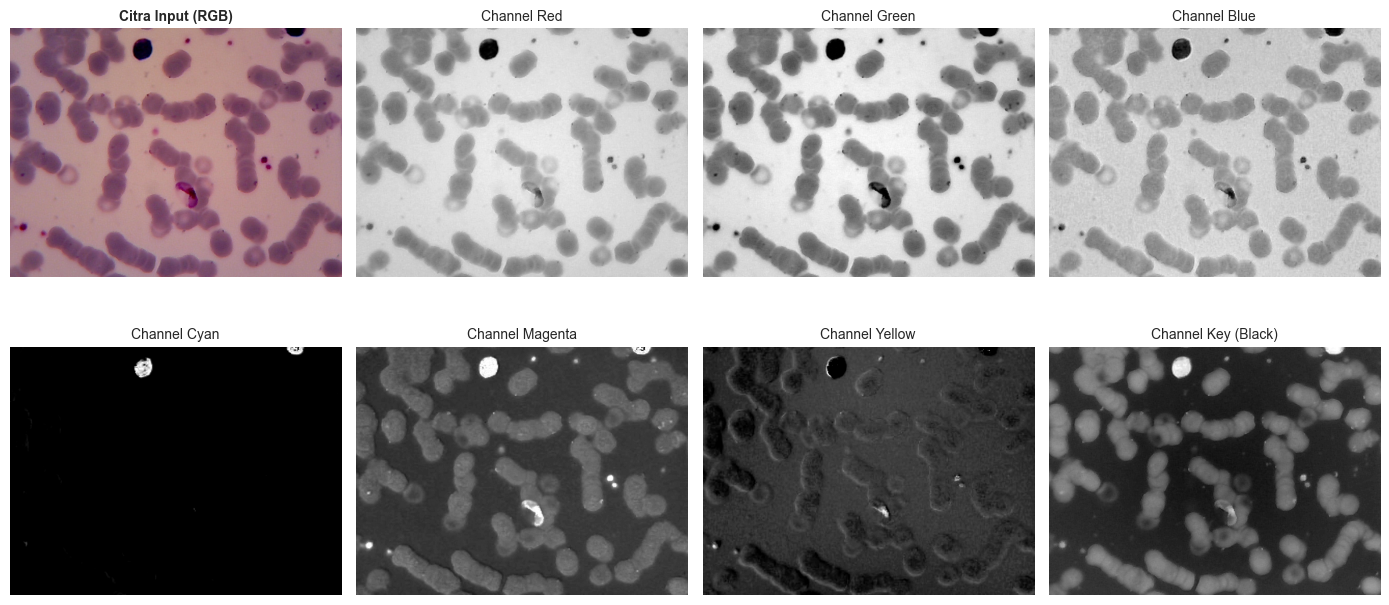

In [9]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. Pemuatan & Validasi Gambar ---
filename = "FG.png"

if not os.path.exists(filename):
    raise FileNotFoundError(f"File '{filename}' tidak ditemukan di lokasi: {os.getcwd()}")

raw_img = cv2.imread(filename)
if raw_img is None:
    raise ValueError("Gagal memuat gambar. Pastikan format file sesuai.")

# Konversi BGR ke RGB
src_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)

# --- 2. Ekstraksi Channel RGB ---
# Menggunakan slicing array (lebih cepat dibanding cv2.split)
red_ch = src_rgb[:, :, 0]
green_ch = src_rgb[:, :, 1]
blue_ch = src_rgb[:, :, 2]

# --- 3. Konversi Ruang Warna ke CMYK ---
# Normalisasi skala [0, 1]
rgb_norm = src_rgb.astype(np.float32) / 255.0

r_norm = rgb_norm[:, :, 0]
g_norm = rgb_norm[:, :, 1]
b_norm = rgb_norm[:, :, 2]

# Hitung komponen Key (Black)
k_ch = 1.0 - np.maximum(np.maximum(r_norm, g_norm), b_norm)

# Hitung komponen Cyan, Magenta, Yellow (dengan proteksi pembagian nol)
denom = 1.0 - k_ch + 1e-7
c_ch = (1.0 - r_norm - k_ch) / denom
m_ch = (1.0 - g_norm - k_ch) / denom
y_ch = (1.0 - b_norm - k_ch) / denom

# Denormalisasi ke uint8 [0, 255]
c_ch = np.clip(c_ch * 255, 0, 255).astype(np.uint8)
m_ch = np.clip(m_ch * 255, 0, 255).astype(np.uint8)
y_ch = np.clip(y_ch * 255, 0, 255).astype(np.uint8)
k_ch = np.clip(k_ch * 255, 0, 255).astype(np.uint8)

# --- 4. Visualisasi Hasil (Layout Modern 2-Baris Terpisah) ---
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Baris 1: Citra Utama & Ruang Warna RGB
axes[0, 0].imshow(src_rgb)
axes[0, 0].set_title("Citra Input (RGB)", fontsize=10, fontweight='bold')

axes[0, 1].imshow(red_ch, cmap="gray")
axes[0, 1].set_title("Channel Red", fontsize=10)

axes[0, 2].imshow(green_ch, cmap="gray")
axes[0, 2].set_title("Channel Green", fontsize=10)

axes[0, 3].imshow(blue_ch, cmap="gray")
axes[0, 3].set_title("Channel Blue", fontsize=10)

# Baris 2: Komponen Ruang Warna CMYK
axes[1, 0].imshow(c_ch, cmap="gray")
axes[1, 0].set_title("Channel Cyan", fontsize=10)

axes[1, 1].imshow(m_ch, cmap="gray")
axes[1, 1].set_title("Channel Magenta", fontsize=10)

axes[1, 2].imshow(y_ch, cmap="gray")
axes[1, 2].set_title("Channel Yellow", fontsize=10)

axes[1, 3].imshow(k_ch, cmap="gray")
axes[1, 3].set_title("Channel Key (Black)", fontsize=10)

# Hilangkan bingkai/aksis pada seluruh subplot
for ax in axes.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()

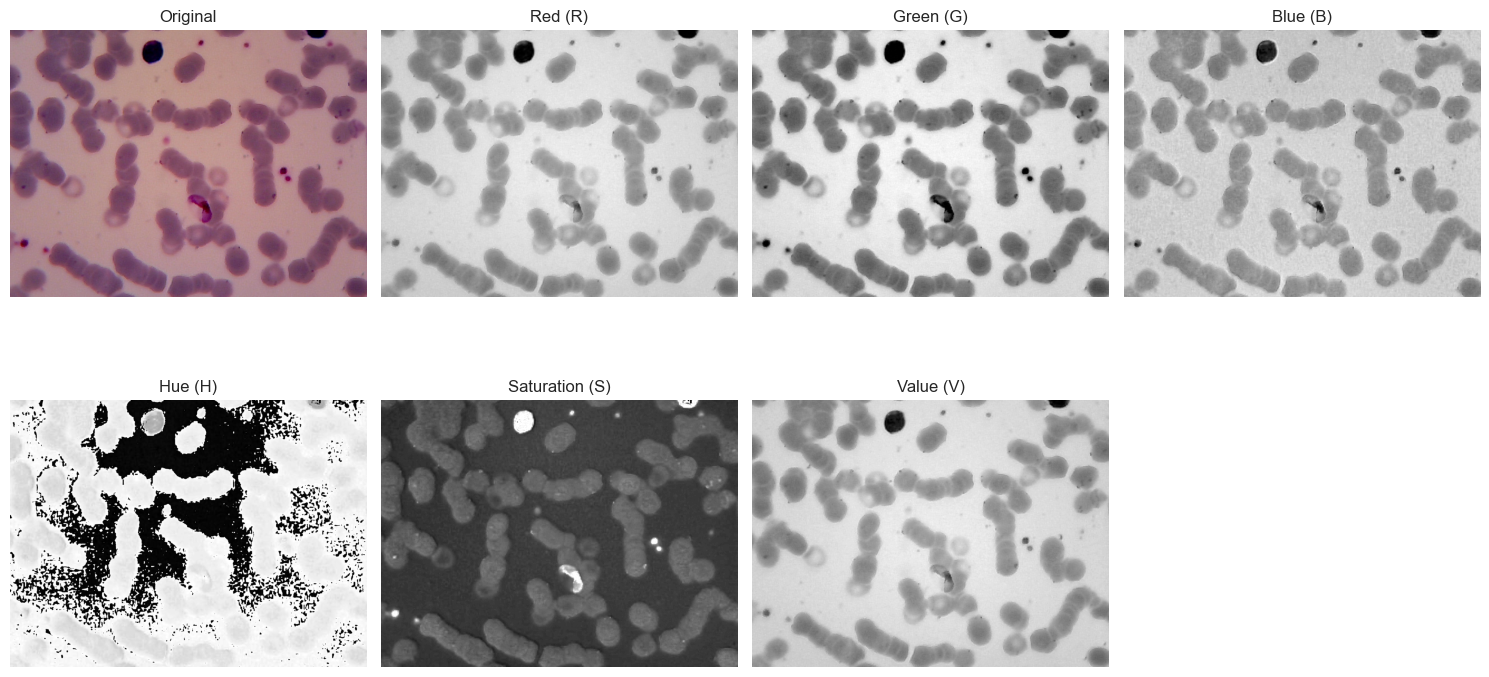

In [10]:
# ======================================================
# Menampilkan komponen R, G, B dan H, S, V (grayscale)
# ======================================================

import cv2
import matplotlib.pyplot as plt

# --- Upload file gambar ---
filename = "FG.png"  # Ganti dengan nama file gambar Anda


# --- Baca gambar ---
img = cv2.imread(filename)   # default BGR
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # konversi ke RGB

# --- Pisahkan channel RGB ---
R, G, B = cv2.split(img)

# --- Konversi ke HSV ---
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv)

# --- Tampilkan hasil ---
plt.figure(figsize=(15,8))

# Gambar asli
plt.subplot(2,4,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

# Komponen RGB
plt.subplot(2,4,2)
plt.imshow(R, cmap="gray")
plt.title("Red (R)")
plt.axis("off")

plt.subplot(2,4,3)
plt.imshow(G, cmap="gray")
plt.title("Green (G)")
plt.axis("off")

plt.subplot(2,4,4)
plt.imshow(B, cmap="gray")
plt.title("Blue (B)")
plt.axis("off")

# Komponen HSV
plt.subplot(2,4,5)
plt.imshow(H, cmap="gray")
plt.title("Hue (H)")
plt.axis("off")

plt.subplot(2,4,6)
plt.imshow(S, cmap="gray")
plt.title("Saturation (S)")
plt.axis("off")

plt.subplot(2,4,7)
plt.imshow(V, cmap="gray")
plt.title("Value (V)")
plt.axis("off")

plt.tight_layout()
plt.show()

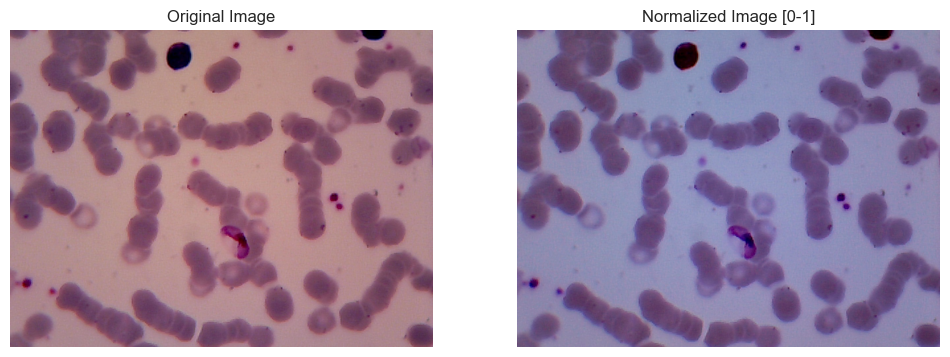

Shape: (960, 1280, 3)
Pixel [0,0] original: [ 88  73 104]
Pixel [0,0] normalized [0-1]: [0.34509805 0.28627452 0.40784314]
Pixel [0,0] normalized [-1,1]: [-0.3098039  -0.42745095 -0.18431371]


In [11]:
# ======================================================
# Normalisasi
# ======================================================

import cv2
import matplotlib.pyplot as plt

# --- Upload file gambar ---
filename = "FG.png"  # Ganti dengan nama file gambar Anda


# --- Baca gambar ---
img = cv2.imread(filename)   # default BGR
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # konversi ke RGB

# Konversi ke RGB (agar sesuai dengan matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 4. Normalisasi citra ke rentang [0,1]
img_norm = img_rgb.astype('float32') / 255.0

# 5. Visualisasi hasil
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Normalized Image [0-1]")
plt.imshow(img_norm)
plt.axis("off")

plt.show()

# 6. (Opsional) Normalisasi ke rentang [-1,1]
img_norm2 = (img_rgb.astype('float32') / 127.5) - 1.0

print("Shape:", img_rgb.shape)
print("Pixel [0,0] original:", img_rgb[0,0])       # misalnya [123 200  50]
print("Pixel [0,0] normalized [0-1]:", img_norm[0,0])  # [0.482 0.784 0.196]
print("Pixel [0,0] normalized [-1,1]:", img_norm2[0,0]) # [-0.035 0.568 -0.608]

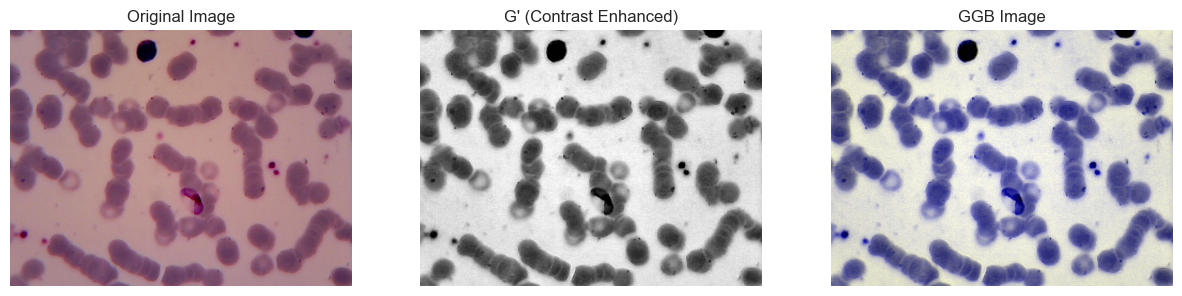

In [12]:
# ======================================================
# GGB
# ======================================================

import cv2
import matplotlib.pyplot as plt

# --- Upload file gambar ---


# --- Baca gambar ---
img = cv2.imread(filename)   # default BGR
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # konversi ke RGB

# 3. Pisahkan channel
R, G, B = cv2.split(img_rgb)

# 4. Hitung G_mean dan B_mean
G_mean = np.mean(G)
B_mean = np.mean(B)

# 5. Normalisasi channel sesuai rumus
Gn = G.astype(np.float32) / G_mean
Bn = B.astype(np.float32) / B_mean

# 6. Konversi Gn menjadi G' dengan contrast adjustment
# (di sini pakai CLAHE untuk peningkatan kontras lokal)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
G_prime = clahe.apply(cv2.normalize(Gn, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8))

# 7. Pastikan Bn diskalakan ke [0,255] agar bisa divisualisasikan
Bn_scaled = cv2.normalize(Bn, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 8. Buat citra baru [G′, G′, Bn]
GGB = cv2.merge([G_prime, G_prime, Bn_scaled])

# 9. Visualisasi hasil
plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("G' (Contrast Enhanced)")
plt.imshow(G_prime, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("GGB Image")
plt.imshow(GGB)
plt.axis("off")

plt.show()

# Tugas

### Ilham Kukuh Febriyansyah

**2320506043**

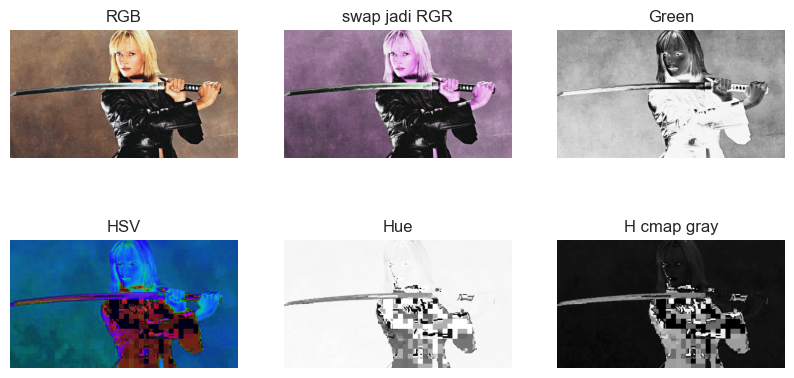

In [14]:
import cv2
import matplotlib.pyplot as plt

filename = "foto-tugas.jpg" 

img = cv2.imread(filename)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

R, G, B = cv2.split(img)

img_swapped = cv2.merge([R, G, R])

plt.figure(figsize=(10, 5))

plt.subplot(2, 3, 1)
plt.imshow(img)
plt.title("RGB")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(img_swapped)
plt.title("swap jadi RGR")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(G)
plt.title("Green")
plt.axis("off")

hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv)

plt.subplot(2, 3, 4)
plt.imshow(hsv)
plt.title("HSV")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(H)
plt.title("Hue")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(H, cmap="gray")
plt.title("H cmap gray")
plt.axis("off")

plt.show()